In [247]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

### Extract mean vectors of 16 viewpoints for the 22 countries in the Mihelač dataset

In [3]:
example_file = "experiment_history/bulgaria_viewpoint1/"

In [5]:
!ls {example_file}/experiment_output_data_folder

66041325144208-cpitch-cpitch-99041325144208-nil-melody-nil-1-both-nil-t-nil-c-nil-t-t-x-3.dat


In [17]:
filepath = "experiment_history/bulgaria_viewpoint2/"\
               "experiment_output_data_folder/"\
               "66041325144208-cpitch-cpitch-99041325144208-nil-melody-nil-1-both-nil-t-nil-c-nil-t-t-x-3.dat"

In [124]:
def get_experiment_data_fpath( experiment_folder_path ):
    # get the file path of the file containing the IDyOM output for a
    # particular country for a particular viewpoint
    fname_list = os.listdir( f"{experiment_folder_path}/experiment_output_data_folder/" )
    fname = fname_list[ 0 ]
    if not fname.endswith( ".dat" ):
        assert False, f"Expected .dat file, got {fname}"
    
    return f"{experiment_folder_path}/experiment_output_data_folder/{fname}"

In [43]:
# one viewpoint's values per country
result_path = get_experiment_data_fpath("experiment_history/croatia_viewpoint1")

In [47]:
# display the first line with the data headers
!head -1 {result_path}

dataset.id melody.id note.id melody.name vertint12 articulation comma voice ornament dyn phrase bioi deltast accidental mpitch cpitch barlength pulses tempo mode keysig dur onset cpitch.order.ltm.cpitch cpitch.order.stm.cpitch cpitch.weight.ltm cpitch.weight.stm cpitch.weight.ltm.cpitch cpitch.weight.stm.cpitch cpitch.probability cpitch.information.content cpitch.entropy cpitch.45 cpitch.47 cpitch.48 cpitch.49 cpitch.50 cpitch.51 cpitch.52 cpitch.53 cpitch.54 cpitch.55 cpitch.56 cpitch.57 cpitch.58 cpitch.59 cpitch.60 cpitch.61 cpitch.62 cpitch.63 cpitch.64 cpitch.65 cpitch.66 cpitch.67 cpitch.68 cpitch.69 cpitch.70 cpitch.71 cpitch.72 cpitch.73 cpitch.74 cpitch.75 cpitch.76 cpitch.77 cpitch.78 cpitch.79 cpitch.80 cpitch.81 cpitch.82 cpitch.83 cpitch.84 cpitch.86 probability information.content entropy information.gain 


The column "information.content" is the third to last

In [44]:
def load_surprise_values_with_header(file_path):
    # get the values in the information content column from
    # a .dat file representing the analysis of one country from
    # one viewpoint
    with open(file_path) as f:
        # Read header line
        header_line = f.readline()
        headers = header_line.strip().split()
        
        # Find the index of 'information.content'
        info_content_index = headers.index("information.content")
        
        # Now read the rest of the data
        surprise_values = []
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.strip().split()
            try:
                value = float(parts[info_content_index])
                surprise_values.append(value)
            except (ValueError, IndexError):
                continue
                
    return np.array(surprise_values)

In [173]:
country_list = [
    "bulgaria",
    "croatia",
    "danemark",
    "france",
    "germany",
    "great_britain",
    "greece",
    "hungary",
    "italy",
    "latvia",
    "netherland",
    "norway",
    "poland",
    "portugal",
    "romania",
    "russia",
    "serbia",
    "slovenia",
    "spain",
    "sweden",
    "switzerland",
    "turkey",
]

In [174]:
# Mapping from abbreviations to full country names in dictionary
abbrev_to_country = {
    "BG": "bulgaria",
    "HR": "croatia",
    "DN": "danemark",
    "FR": "france",
    "DE": "germany",
    "GB": "great_britain",
    "GR": "greece",
    "HU": "hungary",
    "IT": "italy",
    "LV": "latvia",
    "NL": "netherland",
    "NO": "norway",
    "PL": "poland",
    "PT": "portugal",
    "RO": "romania",
    "RU": "russia",
    "RS": "serbia",
    "SI": "slovenia",
    "ES": "spain",
    "SE": "sweden",
    "CH": "switzerland",
    "TR": "turkey",
}

In [175]:
country_to_abbrev = {
    "bulgaria": "BG",
    "croatia": "HR",
    "danemark": "DN",
    "france": "FR" ,
    "germany": "DE",
    "great_britain": "GB",
    "greece": "GR",
    "hungary": "HU",
    "italy": "IT",
    "latvia": "LV",
    "netherland": "NL",
    "norway": "NO",
    "poland": "PL",
    "portugal": "PT",
    "romania": "RO",
    "russia": "RU",
    "serbia": "RS",
    "slovenia": "SI",
    "spain": "ES",
    "sweden": "SE",
    "switzerland": "CH",
    "turkey": "TR",
}

In [176]:
NUM_VIEWPOINTS = 16

Extract the mean value of each viewpoint in a country's melody folder

In [302]:
country_vector = {}

for country in country_list:
    country_vector[ country ] = []

for i, country in enumerate( country_list ):
    for j in range( NUM_VIEWPOINTS ):
        fpath = get_experiment_data_fpath( f"experiment_history/{country}_viewpoint{j+1}" )
        x = load_surprise_values_with_header( fpath )
        country_vector[ country ].append( x.mean() )
    
for country in country_list:
    country_vector[ country ] = np.array( country_vector[ country ] )

In [303]:
country_vector

{'bulgaria': array([1.52522847, 2.75785117, 1.25065316, 1.6045192 , 1.52938467,
        1.68112232, 1.53494524, 1.5204815 , 1.59716953, 1.58014811,
        1.65519517, 1.51433592, 1.47680681, 1.68075728, 1.13965531,
        2.64699764]),
 'croatia': array([1.70871453, 2.7732316 , 1.06451707, 1.78451192, 1.69466382,
        1.8944352 , 1.72431791, 1.69341052, 1.78768784, 1.78982005,
        1.83904537, 1.6951207 , 1.65198657, 1.89028953, 0.98225113,
        2.69096565]),
 'danemark': array([1.82695843, 2.90904286, 1.08208443, 1.89028335, 1.82955016,
        2.03135208, 1.82432152, 1.80116963, 1.89863277, 1.87497957,
        1.92823851, 1.79591275, 1.7778225 , 1.97968432, 1.04619557,
        2.873154  ]),
 'france': array([1.79121451, 2.93026013, 1.13904562, 1.84899532, 1.79949792,
        1.99745516, 1.79265842, 1.77203295, 1.86508794, 1.8483452 ,
        1.89520971, 1.7798277 , 1.75949951, 1.9502332 , 1.02594976,
        2.81716426]),
 'germany': array([1.82050903, 2.91231807, 1.093441

### Show pairwise distances between the countries in the Mihelač dataset

In [304]:
# Country names and matrix of vectors
countries = list(country_vector.keys())
vectors = np.array([country_vector[country] for country in countries])

# Compute Euclidean distance matrix
dist_matrix = cdist(vectors, vectors, metric='euclidean')

# Put into a nicely labeled DataFrame
dist_df = pd.DataFrame(dist_matrix, index=countries, columns=countries)

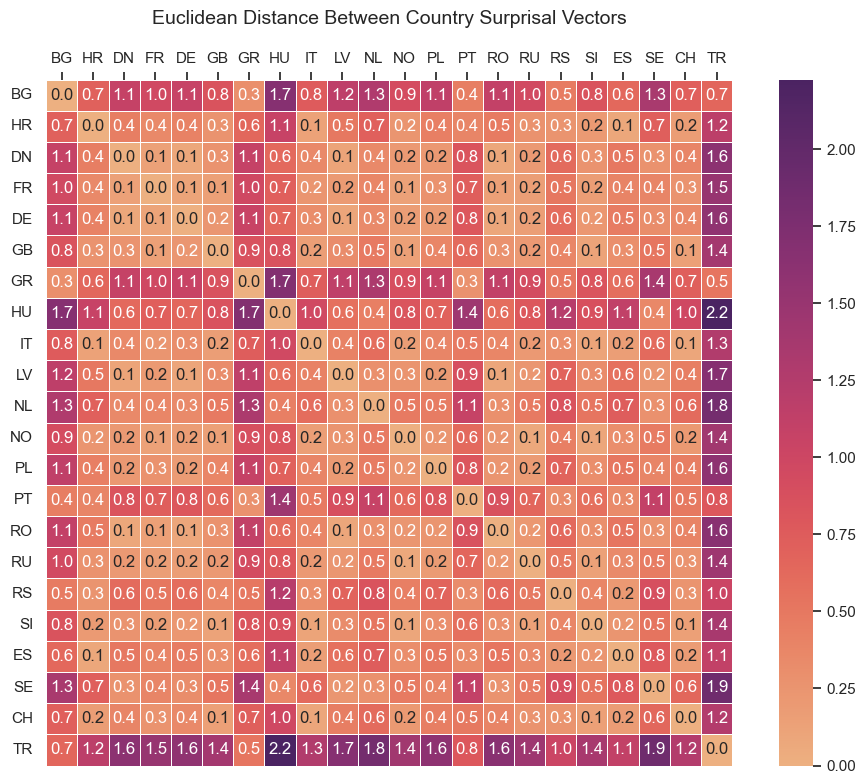

In [305]:
# Define abbreviations for countries
abbreviations = [ country_to_abbrev[ country ] for country in country_list ]

# Create the heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(dist_df, annot=True, fmt=".1f", cmap="flare", linewidths=0.5, square=True, ax=ax,
            cbar=True)

# Move x-axis (column labels) to the top
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

# Set custom tick labels
ax.set_xticklabels(abbreviations, rotation=0, ha='center')
ax.set_yticklabels(abbreviations, rotation=0)

# Add title and layout
plt.title("Euclidean Distance Between Country Surprisal Vectors", pad=40, fontsize=14)
plt.tight_layout()
plt.show()

### Hirerachical Clustering

In [306]:
VIEWPOINT_NAMES = [
    "cpitch",
    "cpitch x dur",
    "dur",
    "inscale",
    "cpint",
    "cpint-size",
    "cpitch-class",
    "cpcint",
    "cpcint-size",
    "contour",
    "newcontour",
    "cpintfref",
    "cpintfip",
    "tessitura",
    "ioi-ratio",
    "onset x ioi-ratio ",
]

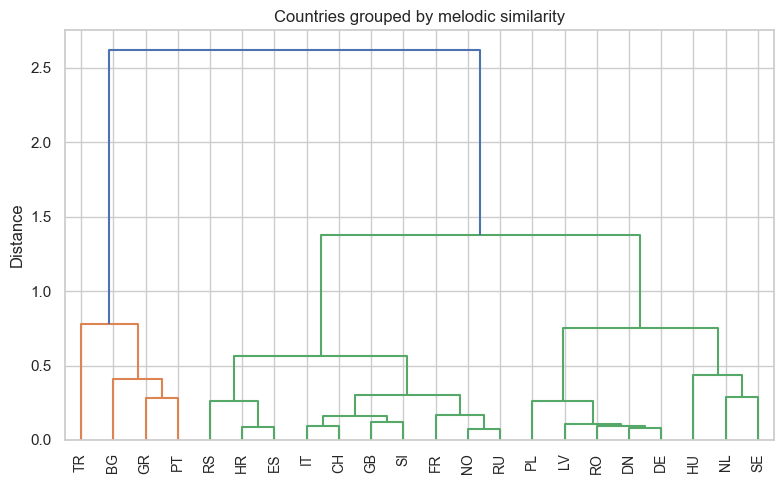

In [308]:
# Create a data matrix in the order of abbreviations
data_matrix = np.stack([country_vector[abbrev_to_country[abbr]] for abbr in abbreviations])
labels = abbreviations  # For dendrogram labeling

# Perform hierarchical clustering
Z = linkage(data_matrix, method='ward')

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels, leaf_rotation=90)
plt.title("Countries grouped by melodic similarity")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### k-Means Clustering

In [208]:
from sklearn.cluster import KMeans
import numpy as np

# Perform k-means clustering
k = 5  # You can adjust this to however many clusters you want
kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
cluster_labels = kmeans.fit_predict(data_matrix)

# Print countries grouped by cluster
from collections import defaultdict

cluster_groups = defaultdict(list)
for abbr, label in zip(abbreviations, cluster_labels):
    cluster_groups[label].append(abbr)

for cluster_id, countries in cluster_groups.items():
    print(f"Cluster {cluster_id}: {', '.join(countries)}")

Cluster 1: BG, GR, PT
Cluster 2: HR, GB, IT, RS, SI, ES, CH
Cluster 0: DN, FR, DE, LV, NO, PL, RO, RU
Cluster 4: HU, NL, SE
Cluster 3: TR


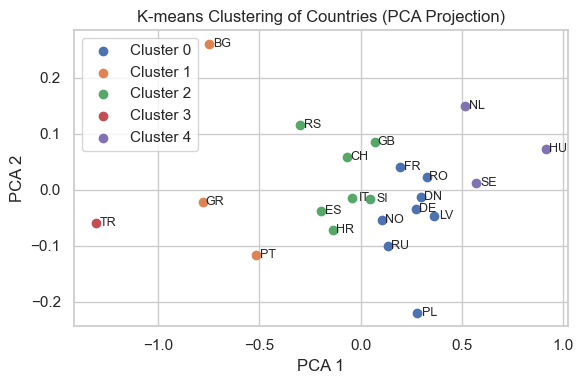

In [310]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data_matrix)

# Plot clusters
plt.figure(figsize=(6, 4))
for i in range(k):
    cluster_points = reduced_data[cluster_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i}')

# Annotate points with country abbreviations
for i, abbr in enumerate(abbreviations):
    plt.text(reduced_data[i, 0]+0.06, reduced_data[i, 1], abbr, fontsize=9, ha='center', va='center',
             )

plt.title("K-means Clustering of Countries (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Add the Borsan dataset to the mix

The Borsan dataset (no deduplication) is predicted as cluster 4.


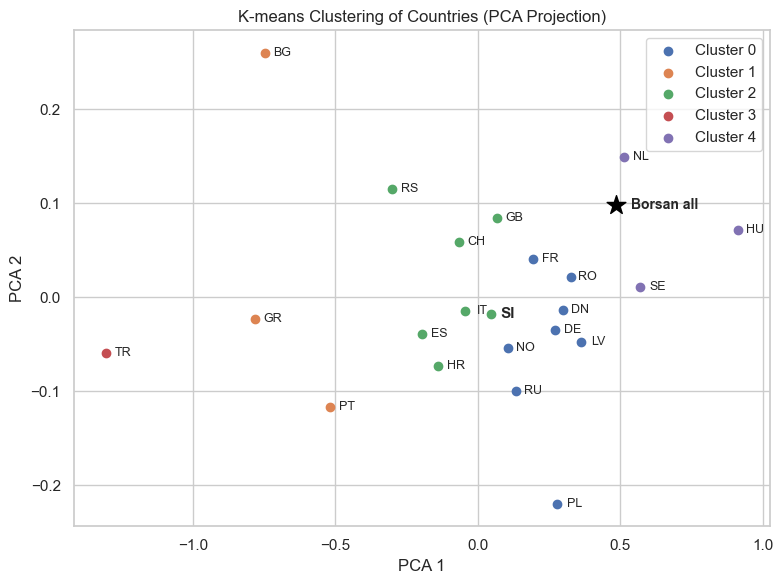

In [240]:
borsan_all = []
for j in range( NUM_VIEWPOINTS ):
    fpath = get_experiment_data_fpath( f"experiment_history/borsan-midi-clean_viewpoint{j+1}" )
    x = load_surprise_values_with_header( fpath )
    borsan_all.append( x.mean() )
borsan_all = np.array( borsan_all )

borsan_all_prediction = kmeans.predict( np.expand_dims( borsan_all, axis=0 ) )
print( f"The Borsan dataset (no deduplication) is predicted as cluster {borsan_all_prediction[0]}.")

# Plot clusters
plt.figure(figsize=(8, 6))
for i in range(k):
    cluster_points = reduced_data[cluster_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i}')

# Annotate points with country abbreviations
for i, abbr in enumerate(abbreviations):
    if abbr == "SI":
        plt.text(reduced_data[i, 0]+0.06, reduced_data[i, 1], abbr, fontsize=11,
                 ha='center', va='center', fontweight="bold")
    else:
        plt.text(reduced_data[i, 0]+0.06, reduced_data[i, 1], abbr, fontsize=9,
                 ha='center', va='center')

plt.title("K-means Clustering of Countries (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Project the new vector into the same PCA space with a special marker
borsan_proj = pca.transform(np.expand_dims(borsan_all, axis=0))
plt.scatter(borsan_proj[0, 0], borsan_proj[0, 1], color='black',
            marker='*', s=200, label='Borsan (new)')
plt.text(borsan_proj[0, 0] + 0.17, borsan_proj[0, 1], 'Borsan all',
         fontsize=10, ha='center', va='center', fontweight='bold')

plt.show()

In [249]:
def print_closer_neighbors( data_matrix, borsan_subset_results, abbreviations ):
    # for a Borsan subset, print all the countries in the Mihelač dataset that
    # show up as closer neighbors than Slovenia
    
    # Compute distances between borsan_all and each country vector
    distances = pairwise_distances(data_matrix, np.expand_dims(borsan_subset_results, axis=0)).flatten()

    # Pair each abbreviation with its distance
    abbr_dist_pairs = list(zip(abbreviations, distances))

    # Sort by distance (nearest first)
    sorted_neighbors = sorted(abbr_dist_pairs, key=lambda x: x[1])


    # Print the results
    for i, ( abbr, dist ) in enumerate( sorted_neighbors ):
        print(f"{i+1}. {abbr}: {dist:.4f}")

        if abbr == "SI":
            break
            
print_closer_neighbors( data_matrix, borsan_all, abbreviations )

1. SE: 0.1504
2. RO: 0.1993
3. LV: 0.2130
4. NL: 0.2304
5. DN: 0.2323
6. DE: 0.2651
7. FR: 0.3067
8. PL: 0.3914
9. RU: 0.4137
10. NO: 0.4195
11. GB: 0.4305
12. HU: 0.4364
13. SI: 0.4622


The Borsan dataset (deduplicated) is predicted as cluster 4.


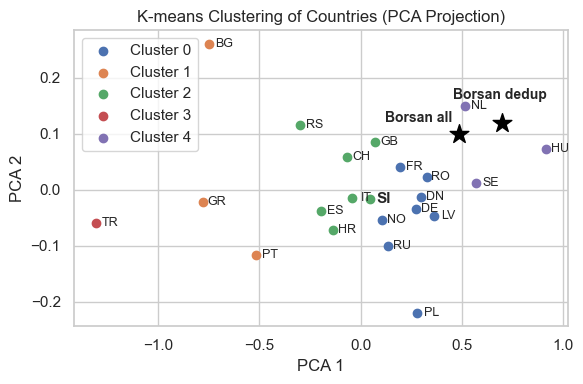

In [322]:
borsan_dedup = []
for j in range( NUM_VIEWPOINTS ):
    fpath = get_experiment_data_fpath( f"experiment_history/borsan-midi-clean-no-dupes_viewpoint{j+1}" )
    x = load_surprise_values_with_header( fpath )
    borsan_dedup.append( x.mean() )
borsan_dedup = np.array( borsan_dedup )

borsan_dedup_prediction = kmeans.predict( np.expand_dims( borsan_dedup, axis=0 ) )

print( f"The Borsan dataset (deduplicated) is predicted as cluster {borsan_dedup_prediction[0]}.")

# Plot clusters
plt.figure(figsize=(6, 4))
for i in range(k):
    cluster_points = reduced_data[cluster_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i}')

# Annotate points with country abbreviations
for i, abbr in enumerate(abbreviations):
    if abbr == "SI":
        plt.text(reduced_data[i, 0]+0.07, reduced_data[i, 1], abbr, fontsize=11,
                 ha='center', va='center', fontweight="bold")
    else:
        plt.text(reduced_data[i, 0]+0.07, reduced_data[i, 1], abbr, fontsize=9,
                 ha='center', va='center')

plt.title("K-means Clustering of Countries (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Project the new vector into the same PCA space with a special marker
borsan_proj = pca.transform(np.expand_dims(borsan_all, axis=0))
plt.scatter(borsan_proj[0, 0], borsan_proj[0, 1], color='black',
            marker='*', s=200, label='Borsan (new)')
plt.text(borsan_proj[0, 0]- 0.2, borsan_proj[0, 1] + 0.03, 'Borsan all',
         fontsize=10, ha='center', va='center', fontweight='bold')

# Project the new vector into the same PCA space with a special marker
borsan_proj_dedup = pca.transform(np.expand_dims(borsan_dedup, axis=0))
plt.scatter(borsan_proj_dedup[0, 0], borsan_proj_dedup[0, 1], color='black',
            marker='*', s=200, label='Borsan (new)')
plt.text(borsan_proj[0, 0]+0.2, borsan_proj[0, 1]+0.07, 'Borsan dedup',
         fontsize=10, ha='center', va='center', fontweight='bold')

plt.show()

In [250]:
print_closer_neighbors( data_matrix, borsan_dedup, abbreviations )

1. SE: 0.1883
2. HU: 0.2352
3. NL: 0.2977
4. LV: 0.3875
5. RO: 0.3966
6. DN: 0.4285
7. DE: 0.4622
8. FR: 0.5163
9. PL: 0.5491
10. RU: 0.6125
11. NO: 0.6246
12. GB: 0.6405
13. SI: 0.6727


In [254]:
def regional_data( region_name ):
    # get vector of a results for regional subset
    
    borsan_region = []
    for j in range( NUM_VIEWPOINTS ):
        fpath = get_experiment_data_fpath( f"experiment_history/borsan-regional-{region_name}_viewpoint{j+1}" )
        x = load_surprise_values_with_header( fpath )
        borsan_region.append( x.mean() )

    return np.array( borsan_region )

stajerska = regional_data( "Štajerska" )

In [256]:
def regional_prediction( region_data, region_name, kmeans ):
    # predict the cluster for a regional subset
    
    region_prediction = kmeans.predict( np.expand_dims( region_data, axis=0 ) )

    print( f"The {region_name} regional subset is predicted as cluster {region_prediction[0]}.")

regional_prediction( stajerska, "Štajerska", kmeans )

The Štajerska regional subset is predicted as cluster 4.


In [257]:
print_closer_neighbors( data_matrix, stajerska, abbreviations )

1. SE: 0.1959
2. LV: 0.2629
3. RO: 0.3317
4. PL: 0.3363
5. DN: 0.3411
6. DE: 0.3490
7. NL: 0.3550
8. HU: 0.3925
9. FR: 0.4474
10. RU: 0.4700
11. NO: 0.5047
12. SI: 0.5721


In [264]:
gorenjska = regional_data( "Gorenjska" )
regional_prediction( gorenjska, "Gorenjska", kmeans )
print_closer_neighbors( data_matrix, gorenjska, abbreviations )

The Gorenjska regional subset is predicted as cluster 4.
1. HU: 0.5737
2. SE: 0.9064
3. NL: 0.9720
4. LV: 1.1276
5. RO: 1.1425
6. DN: 1.1736
7. DE: 1.2103
8. PL: 1.2644
9. FR: 1.2666
10. RU: 1.3572
11. NO: 1.3738
12. GB: 1.3864
13. SI: 1.4240


In [261]:
dolenjska = regional_data( "Dolenjska" )
regional_prediction( dolenjska, "Dolenjska", kmeans )
print_closer_neighbors( data_matrix, dolenjska, abbreviations )

The dolenjska regional subset is predicted as cluster 0.
1. DE: 0.0831
2. LV: 0.1250
3. RO: 0.1265
4. DN: 0.1308
5. FR: 0.1452
6. RU: 0.1963
7. NO: 0.2078
8. PL: 0.2112
9. SI: 0.2520


In [262]:
prekmurje = regional_data( "Prekmurje" )
regional_prediction( prekmurje, "Prekmurje", kmeans )
print_closer_neighbors( data_matrix, prekmurje, abbreviations )

The Prekmurje regional subset is predicted as cluster 2.
1. GB: 0.2556
2. CH: 0.2899
3. FR: 0.3126
4. SI: 0.3206


In [263]:
primorska = regional_data( "Primorska" )
regional_prediction( primorska, "Primorska", kmeans )
print_closer_neighbors( data_matrix, primorska, abbreviations )

The Primorska regional subset is predicted as cluster 4.
1. HU: 0.1307
2. SE: 0.3451
3. NL: 0.3620
4. LV: 0.5238
5. RO: 0.5433
6. DN: 0.5862
7. DE: 0.6045
8. FR: 0.6639
9. PL: 0.6747
10. RU: 0.7546
11. NO: 0.7692
12. GB: 0.7837
13. SI: 0.8205


In [267]:
region_names_vectors = [
    ( "Štajerska", stajerska ),
    ( "Gorenjska", gorenjska ),
    ( "Dolenjska", dolenjska ),
    ( "Prekmurje", prekmurje ),
    ( "Primorska", primorska ),
]

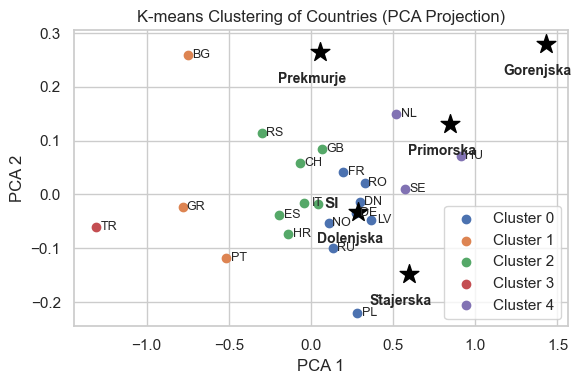

In [285]:
# Plot clusters
plt.figure(figsize=(6, 4))
for i in range(k):
    cluster_points = reduced_data[cluster_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i}')

# Annotate points with country abbreviations
for i, abbr in enumerate(abbreviations):
    if abbr == "SI":
        plt.text(reduced_data[i, 0]+0.08, reduced_data[i, 1], abbr, fontsize=11,
                 ha='center', va='center', fontweight="bold")
    else:
        plt.text(reduced_data[i, 0]+0.08, reduced_data[i, 1], abbr, fontsize=9,
                 ha='center', va='center')

plt.title("K-means Clustering of Countries (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.tight_layout()

for region_name, region_vector in region_names_vectors:
    # Project the new vector into the same PCA space with a special marker
    borsan_proj = pca.transform(np.expand_dims(region_vector, axis=0))
    plt.scatter(borsan_proj[0, 0], borsan_proj[0, 1], color='black',
                marker='*', s=200, label='Borsan (new)')
    plt.text(borsan_proj[0, 0] - 0.05, borsan_proj[0, 1] - 0.05, region_name,
             fontsize=10, ha='center', va='center', fontweight='bold')

plt.show()

### Hierarchical Clustering with Borsan dataset

In [295]:
country_vector[ "borsan_all" ] = borsan_all
country_vector[ "borsan_dedup" ] = borsan_dedup
country_vector

{'bulgaria': array([1.52522847, 2.75785117, 1.25065316, 1.6045192 , 1.52938467,
        1.68112232, 1.53494524, 1.5204815 , 1.59716953, 1.58014811,
        1.65519517, 1.51433592, 1.47680681, 1.68075728, 1.13965531,
        2.64699764]),
 'croatia': array([1.70871453, 2.7732316 , 1.06451707, 1.78451192, 1.69466382,
        1.8944352 , 1.72431791, 1.69341052, 1.78768784, 1.78982005,
        1.83904537, 1.6951207 , 1.65198657, 1.89028953, 0.98225113,
        2.69096565]),
 'danemark': array([1.82695843, 2.90904286, 1.08208443, 1.89028335, 1.82955016,
        2.03135208, 1.82432152, 1.80116963, 1.89863277, 1.87497957,
        1.92823851, 1.79591275, 1.7778225 , 1.97968432, 1.04619557,
        2.873154  ]),
 'france': array([1.79121451, 2.93026013, 1.13904562, 1.84899532, 1.79949792,
        1.99745516, 1.79265842, 1.77203295, 1.86508794, 1.8483452 ,
        1.89520971, 1.7798277 , 1.75949951, 1.9502332 , 1.02594976,
        2.81716426]),
 'germany': array([1.82050903, 2.91231807, 1.093441

In [297]:
abbreviations += [ "BRS[all]", "BRS[dedup]" ]

In [299]:
abbrev_to_country[ "BRS[all]" ] = "borsan_all"
abbrev_to_country[ "BRS[dedup]" ] = "borsan_dedup"

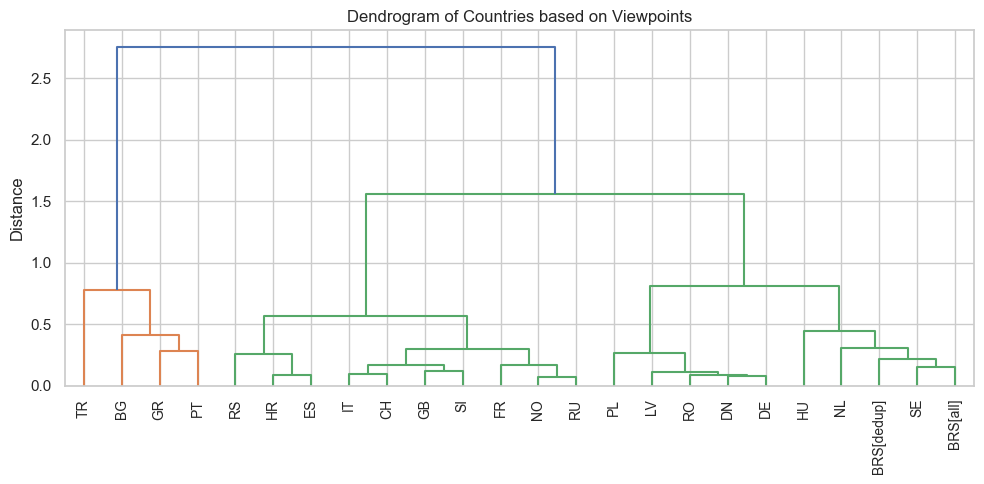

In [300]:
# Create a data matrix in the order of abbreviations
data_matrix = np.stack([country_vector[abbrev_to_country[abbr]] for abbr in abbreviations])
labels = abbreviations  # For dendrogram labeling

# Perform hierarchical clustering
Z = linkage(data_matrix, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=labels, leaf_rotation=90)
plt.title("Dendrogram of Countries based on Viewpoints")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()